# Customer Churn Prediction: End-to-End Walkthrough

A complete churn-modelling workflow on the **IBM Telco Customer Churn** dataset. This notebook shows the full data-science process: exploratory analysis with [`eda-kit`](https://github.com/sahindemirbas/eda-kit), preprocessing, modelling with a Random Forest, and interpretation of what actually drives churn.

> The same steps run in one place via `python src/train_model.py`.

## Business context

Churn (customers leaving) is one of the most expensive problems a subscription business faces. **Acquiring a new customer costs far more than keeping an existing one**, so identifying who is likely to churn before they leave lets a company target retention offers efficiently. The goal here is to predict churn and, just as importantly, to understand *why* customers churn so the business can act.

In [1]:
import pandas as pd
import eda_kit as ek

DATA_URL = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
    "master/data/Telco-Customer-Churn.csv"
)
df = pd.read_csv(DATA_URL)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data overview
Let eda-kit give us the full structural picture at once.

In [2]:
ek.check_df(df)

###################### Shape ######################
(7043, 21)
###################### Types ######################
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
###################### Head ######################
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34         

## 2. Know the columns
Classify columns into categorical / numerical / cardinal before touching anything.

In [3]:
cat_cols, num_cols, card_cols = ek.grab_col_names(df)
print("categorical:", cat_cols)
print("numerical:", num_cols)
print("cardinal (drop):", card_cols)

Observations: 7043
Variables: 21
cat_cols: 17
num_cols: 2
cat_but_car: 2
num_but_cat: 1
categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'SeniorCitizen']
numerical: ['tenure', 'MonthlyCharges']
cardinal (drop): ['customerID', 'TotalCharges']


## 3. Target distribution
Churn is imbalanced (~26% churn). That is why accuracy alone is a misleading metric here and why we use ROC-AUC and look at the baseline.

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


<Axes: title={'center': 'Churn distribution'}, xlabel='Churn'>

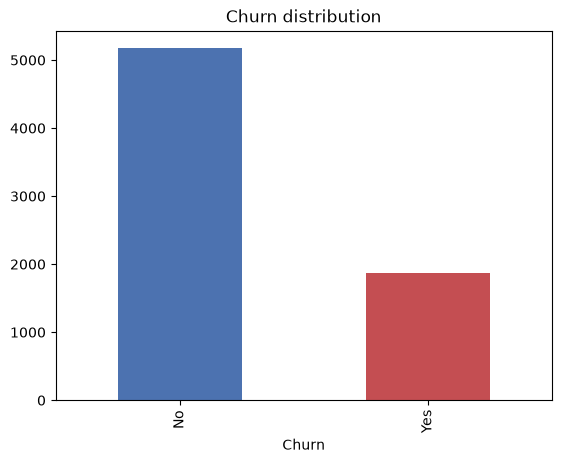

In [4]:
print(df['Churn'].value_counts(normalize=True).round(3))
df['Churn'].value_counts().plot(kind='bar', title='Churn distribution', color=['#4c72b0','#c44e52'])

## 4. Missing values

In [5]:
na_cols = ek.missing_values_table(df, na_name=True)
print(na_cols)

Empty DataFrame
Columns: [n_miss, ratio]
Index: []
[]


## 5. Cleanup: TotalCharges coercion
`TotalCharges` is stored as text with a few blanks. We coerce to numeric and drop the ~11 rows that are new customers with no total yet.

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print('rows after clean:', len(df))

# refresh column types after the dtype change
cat_cols, num_cols, card_cols = ek.grab_col_names(df)

rows after clean: 7032
Observations: 7032
Variables: 21
cat_cols: 17
num_cols: 3
cat_but_car: 1
num_but_cat: 1


## 6. Outliers: cap, don't drop

In [7]:
for col in num_cols:
    if ek.check_outlier(df, col):
        print(f'  {col}: outliers -> capping')
        ek.replace_with_thresholds(df, col)
    else:
        print(f'  {col}: clean')

  tenure: clean
  MonthlyCharges: clean
  TotalCharges: clean


## 7. Encode categoricals
Collapse rare classes first, then one-hot encode (keeping the target out of encoding).

In [8]:
encode_cols = [c for c in cat_cols if c != 'Churn']
df = ek.rare_encoder(df, rare_perc=0.01)
df = ek.one_hot_encoder(df, encode_cols)
print('encoded shape:', df.shape)

# drop high-cardinality / ID columns before modelling
df = df.drop(columns=card_cols)
print('after dropping cardinal cols:', df.shape)

encoded shape: (7032, 32)
after dropping cardinal cols: (7032, 31)


## 8. Train / test split (stratified)

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = (df['Churn'] == 'Yes').astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('train:', X_tr.shape, '| test:', X_te.shape)
print('churn rate train/test:', round(y_tr.mean(),3), round(y_te.mean(),3))

train: (5625, 30) | test: (1407, 30)
churn rate train/test: 0.266 0.266


## 9. Baselines first
A **dummy** (always predict the majority class) establishes the floor. Any real model must beat it, especially on ROC-AUC, where the dummy sits at 0.5.

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall': recall_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
        'roc_auc': roc_auc_score(y_te, y_proba),
    }

base = DummyClassifier(strategy='most_frequent').fit(X_tr, y_tr)
print('Baseline:', evaluate(base, X_te, y_te))

Baseline: {'accuracy': 0.7341862117981521, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.5}


/Users/sahindemirbas/Desktop/GitHubProjects/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 10. Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1)
model.fit(X_tr, y_tr)
metrics = evaluate(model, X_te, y_te)
print('RandomForest:', {k: round(v,4) for k,v in metrics.items()})

RandomForest: {'accuracy': 0.7946, 'precision': 0.6451, 'recall': 0.5053, 'f1': 0.5667, 'roc_auc': 0.8361}


## 10b. Is 0.84 just one lucky split? (5-fold CV)

A single train/test split could be unusually easy or hard. To check the result is stable, we repeat the fit across 5 stratified folds and report the mean +/- 1 std of each metric. The dummy classifier is cross-validated too, so we can compare like for like.


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate

scoring = {'accuracy':'accuracy','precision':'precision','recall':'recall','f1':'f1','roc_auc':'roc_auc'}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rf = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
cv_base = cross_validate(base, X, y, cv=cv, scoring=scoring, n_jobs=-1)

import pandas as pd
rows=[]
for m in scoring:
    rows.append({'metric': m,
                 'RandomForest mean': round(cv_rf['test_'+m].mean(),3),
                 'RF std': round(cv_rf['test_'+m].std(),3),
                 'Baseline mean': round(cv_base['test_'+m].mean(),3)})
pd.DataFrame(rows).set_index('metric')


/Users/sahindemirbas/Desktop/GitHubProjects/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sahindemirbas/Desktop/GitHubProjects/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sahindemirbas/Desktop/GitHubProjects/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples.

/Users/sahindemirbas/Desktop/GitHubProjects/customer-churn-prediction/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,RandomForest mean,RF std,Baseline mean
metric,,,
accuracy,0.805,0.006,0.734
precision,0.677,0.020,0.000
recall,0.512,0.003,0.000
f1,0.583,0.009,0.000
roc_auc,0.845,0.004,0.500


## 11. Confusion matrix

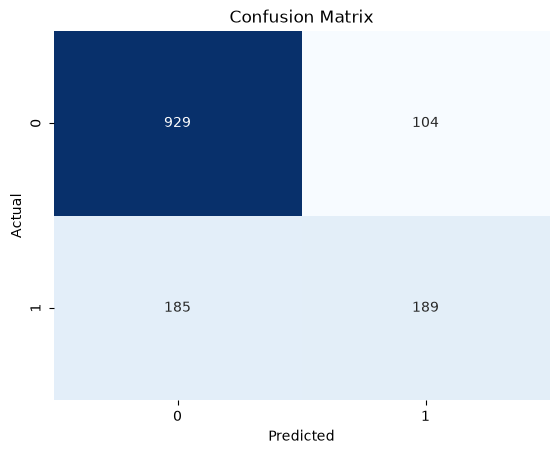

In [13]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_te, model.predict(X_te))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

## 12. What drives churn?
The most important features are business-readable: **tenure**, **total & monthly charges**, **fiber-optic internet**, **short contracts** and **electronic-check payment** stand out. Together they sketch the classic profile of a higher-value, month-to-month customer at risk.

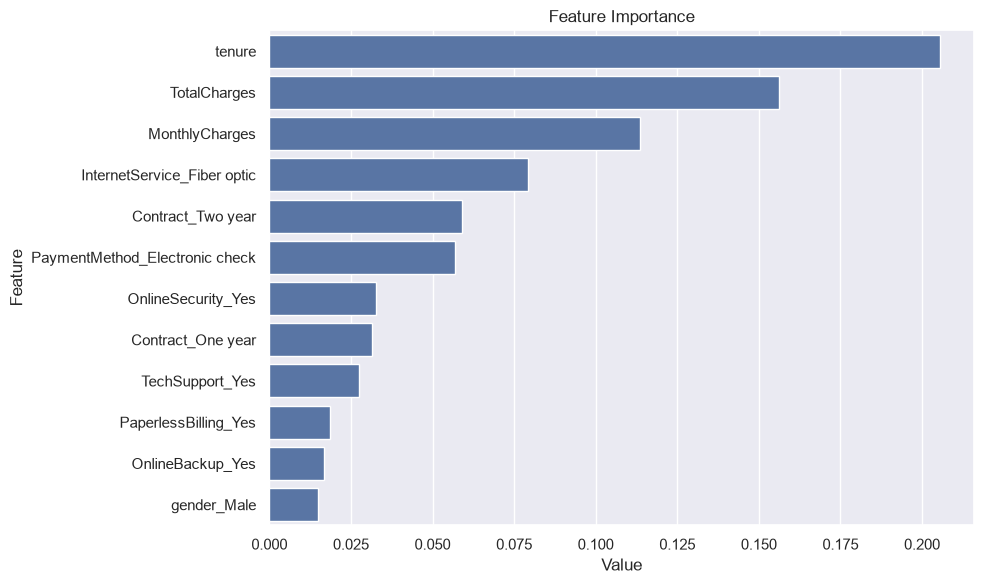

In [14]:
ek.plot_importance(model, X_tr, num=12)

## 13. Business takeaways

- **Tenure is the strongest signal.** Churn concentrates in the first months, so early onboarding and loyalty incentives pay off.
- **Month-to-month + electronic check** is a high-risk combination. Push annual contracts and autopay.
- **Fiber-optic users churn more.** Likely a service-quality / price perception issue worth investigating (not just "sell fiber").
- **Retention should target *before* customers become high spenders then leave**. Use predicted churn probability as a prioritization score for CRM outreach.

> These are exactly the kind of insights a data analyst turns into a dashboard and a retention campaign, not just a model report.